In [ ]:
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

FINAL_FOLDER = os.path.join(
    BASE_PATH,
    "Final_Frozen_Model"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [ ]:
config_path = os.path.join(
    FINAL_FOLDER,
    "final_config.json"
)

with open(config_path, "r") as f:
    final_config = json.load(f)

print("========== FINAL FROZEN CONFIGURATION ==========")

for key, value in final_config.items():
    print(f"{key}: {value}")

========== FINAL FROZEN CONFIGURATION ==========
project_stage: FINAL FROZEN MODEL
model: U-Net
dataset: Dataset V1
dataset_split: Dataset_V1_frozen_split.json
input_size: [256, 256]
input_channels: 3
output_channels: 3
loss_function: L1Loss
optimizer: Adam
selected_learning_rate: 0.0001
training_epochs: 5
selected_validation_loss: 0.1759122337984002
model_file: final_unet_model.pth
preprocessing: RGB conversion, resize to 256x256, normalize to [0,1]
status: FROZEN


In [ ]:
split_path = os.path.join(
    FINAL_FOLDER,
    "Dataset_V1_frozen_split.json"
)

with open(split_path, "r") as f:
    split_data = json.load(f)

train_pairs = [
    tuple(x)
    for x in split_data["train"]
]

val_pairs = [
    tuple(x)
    for x in split_data["validation"]
]

test_pairs = [
    tuple(x)
    for x in split_data["test"]
]

print("Training samples   :", len(train_pairs))
print("Validation samples :", len(val_pairs))
print("TEST samples       :", len(test_pairs))

Training samples   : 863
Validation samples : 184
TEST samples       : 186


In [ ]:
class UnderwaterDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        input_path, target_path = self.pairs[index]

        input_image = Image.open(
            input_path
        ).convert("RGB")

        target_image = Image.open(
            target_path
        ).convert("RGB")

        input_image = input_image.resize(
            (256, 256)
        )

        target_image = target_image.resize(
            (256, 256)
        )

        input_image = (
            np.array(input_image)
            .astype(np.float32) / 255.0
        )

        target_image = (
            np.array(target_image)
            .astype(np.float32) / 255.0
        )

        input_image = torch.tensor(
            input_image
        ).permute(2, 0, 1)

        target_image = torch.tensor(
            target_image
        ).permute(2, 0, 1)

        return input_image, target_image

In [ ]:
test_dataset = UnderwaterDataset(
    test_pairs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print(
    "Test dataset size:",
    len(test_dataset)
)

Test dataset size: 186


In [ ]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.conv3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            stride=2
        )

        self.conv1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv2d(
            32,
            3,
            1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        m = self.middle(p3)

        u3 = self.up3(m)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.conv3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.conv2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.conv1(u1)

        return torch.sigmoid(
            self.final(u1)
        )

In [ ]:
final_model_path = os.path.join(
    FINAL_FOLDER,
    "final_unet_model.pth"
)

final_model = UNet().to(device)

final_model.load_state_dict(
    torch.load(
        final_model_path,
        map_location=device
    )
)

final_model.eval()

print("================================")
print("FINAL MODEL LOADED")
print("================================")
print("Status: FROZEN")
print("Model: U-Net")
print("Model path:")
print(final_model_path)

FINAL MODEL LOADED
Status: FROZEN
Model: U-Net
Model path:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Final_Frozen_Model/final_unet_model.pth


In [ ]:
criterion = nn.L1Loss()

test_loss_total = 0.0
test_samples = 0

all_test_inputs = []
all_test_outputs = []
all_test_targets = []

with torch.no_grad():

    for inputs, targets in test_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = final_model(inputs)

        loss = criterion(
            outputs,
            targets
        )

        batch_size = inputs.size(0)

        test_loss_total += (
            loss.item() * batch_size
        )

        test_samples += batch_size

        all_test_inputs.append(
            inputs.cpu()
        )

        all_test_outputs.append(
            outputs.cpu()
        )

        all_test_targets.append(
            targets.cpu()
        )

test_l1 = (
    test_loss_total /
    test_samples
)

all_test_inputs = torch.cat(
    all_test_inputs
)

all_test_outputs = torch.cat(
    all_test_outputs
)

all_test_targets = torch.cat(
    all_test_targets
)

print(
    "Final Test L1 Loss:",
    round(test_l1, 6)
)

Final Test L1 Loss: 0.175869


In [ ]:
def calculate_psnr(
    output,
    target
):

    mse = np.mean(
        (output - target) ** 2
    )

    if mse == 0:
        return float("inf")

    return 10 * np.log10(
        1.0 / mse
    )

In [ ]:
psnr_values = []

for i in range(
    len(all_test_outputs)
):

    output = (
        all_test_outputs[i]
        .permute(1, 2, 0)
        .numpy()
    )

    target = (
        all_test_targets[i]
        .permute(1, 2, 0)
        .numpy()
    )

    psnr = calculate_psnr(
        output,
        target
    )

    psnr_values.append(psnr)

mean_psnr = np.mean(
    psnr_values
)

print(
    "Mean Test PSNR:",
    round(mean_psnr, 4),
    "dB"
)

Mean Test PSNR: 13.0429 dB


In [ ]:
!pip -q install scikit-image

In [ ]:
from skimage.metrics import structural_similarity

In [ ]:
ssim_values = []

for i in range(
    len(all_test_outputs)
):

    output = (
        all_test_outputs[i]
        .permute(1, 2, 0)
        .numpy()
    )

    target = (
        all_test_targets[i]
        .permute(1, 2, 0)
        .numpy()
    )

    score = structural_similarity(
        output,
        target,
        channel_axis=2,
        data_range=1.0
    )

    ssim_values.append(score)

mean_ssim = np.mean(
    ssim_values
)

print(
    "Mean Test SSIM:",
    round(mean_ssim, 4)
)

Mean Test SSIM: 0.5052


In [ ]:
test_image_errors = []

for i in range(
    len(all_test_outputs)
):

    error = torch.mean(
        torch.abs(
            all_test_outputs[i]
            -
            all_test_targets[i]
        )
    ).item()

    test_image_errors.append(
        error
    )

test_image_errors = np.array(
    test_image_errors
)

print(
    "Mean image-wise L1:",
    test_image_errors.mean()
)

print(
    "Minimum:",
    test_image_errors.min()
)

print(
    "Maximum:",
    test_image_errors.max()
)

Mean image-wise L1: 0.1758692553367025
Minimum: 0.07383019477128983
Maximum: 0.43548646569252014


In [ ]:
# Warm-up
with torch.no_grad():

    for inputs, _ in test_loader:

        inputs = inputs.to(device)

        _ = final_model(inputs)

        break


if device.type == "cuda":
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():

    for inputs, _ in test_loader:

        inputs = inputs.to(device)

        _ = final_model(inputs)

if device.type == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()

total_inference_time = (
    end_time - start_time
)

num_test_images = len(
    test_dataset
)

average_time_per_image = (
    total_inference_time /
    num_test_images
)

images_per_second = (
    num_test_images /
    total_inference_time
)

print(
    "Total inference time:",
    round(total_inference_time, 4),
    "seconds"
)

print(
    "Average time/image:",
    round(average_time_per_image, 6),
    "seconds"
)

print(
    "Images/second:",
    round(images_per_second, 2)
)

Total inference time: 1.6633 seconds
Average time/image: 0.008943 seconds
Images/second: 111.83


In [ ]:
total_parameters = sum(
    p.numel()
    for p in final_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in final_model.parameters()
    if p.requires_grad
)

model_size_mb = (
    os.path.getsize(
        final_model_path
    )
    / (1024 ** 2)
)

print("========== MODEL INFORMATION ==========")

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

print(
    "Model size:",
    round(model_size_mb, 4),
    "MB"
)

========== MODEL INFORMATION ==========
Total parameters: 1925667
Trainable parameters: 1925667
Model size: 7.359 MB


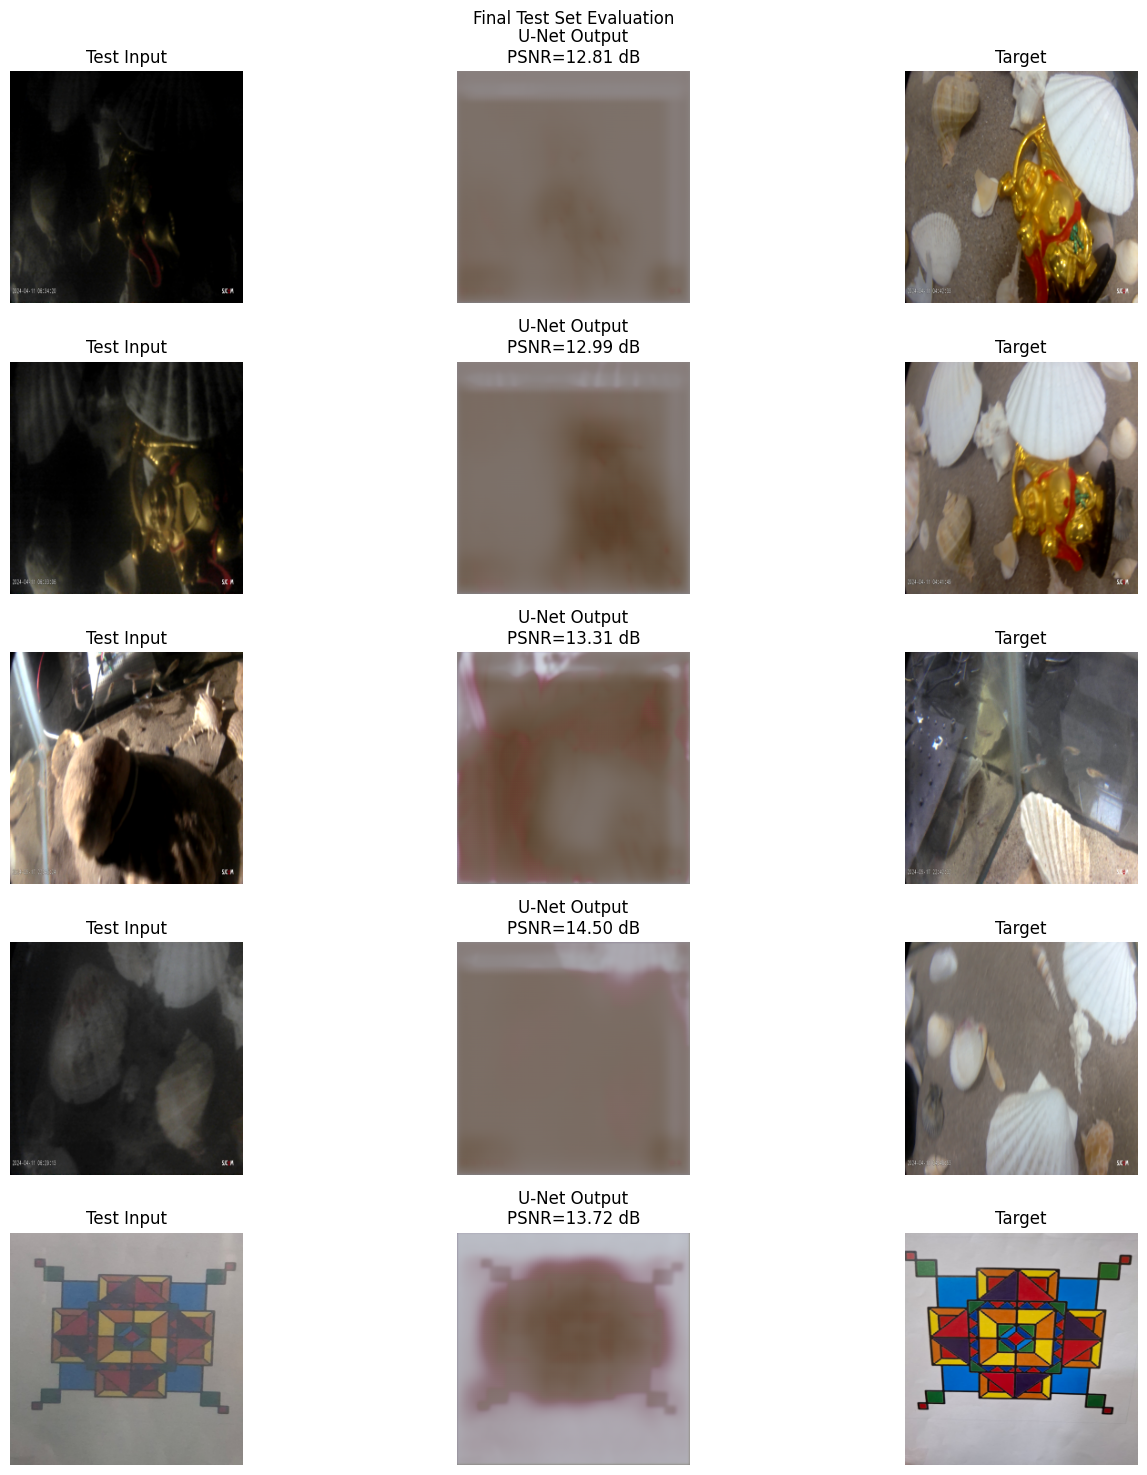

In [ ]:
num_images = min(
    5,
    len(all_test_inputs)
)

plt.figure(
    figsize=(15, 15)
)

for i in range(num_images):

    input_img = (
        all_test_inputs[i]
        .permute(1, 2, 0)
        .numpy()
    )

    output_img = (
        all_test_outputs[i]
        .permute(1, 2, 0)
        .numpy()
    )

    target_img = (
        all_test_targets[i]
        .permute(1, 2, 0)
        .numpy()
    )

    plt.subplot(
        num_images,
        3,
        i * 3 + 1
    )

    plt.imshow(input_img)
    plt.title("Test Input")
    plt.axis("off")

    plt.subplot(
        num_images,
        3,
        i * 3 + 2
    )

    plt.imshow(output_img)

    plt.title(
        f"U-Net Output\n"
        f"PSNR={psnr_values[i]:.2f} dB"
    )

    plt.axis("off")

    plt.subplot(
        num_images,
        3,
        i * 3 + 3
    )

    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

plt.suptitle(
    "Final Test Set Evaluation"
)

plt.tight_layout()
plt.show()

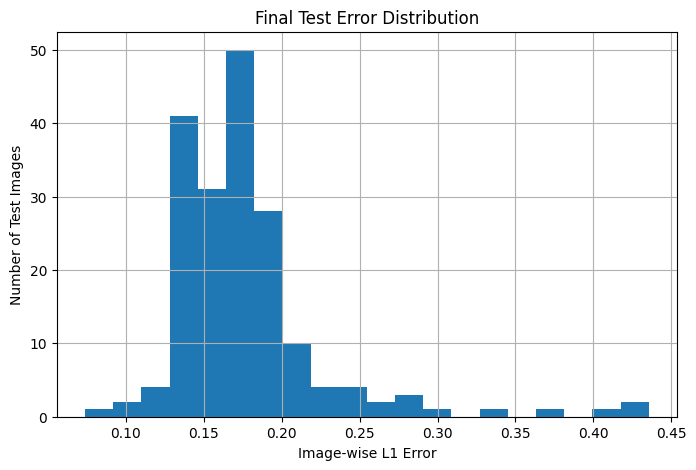

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    test_image_errors,
    bins=20
)

plt.xlabel(
    "Image-wise L1 Error"
)

plt.ylabel(
    "Number of Test Images"
)

plt.title(
    "Final Test Error Distribution"
)

plt.grid()

plt.show()

In [ ]:
day23_results = {

    "evaluation":
        "Final held-out test evaluation",

    "model":
        "Frozen U-Net",

    "dataset":
        "Dataset V1",

    "test_samples":
        len(test_dataset),

    "learning_rate":
        final_config[
            "selected_learning_rate"
        ],

    "test_L1_loss":
        float(test_l1),

    "mean_PSNR_dB":
        float(mean_psnr),

    "mean_SSIM":
        float(mean_ssim),

    "mean_image_wise_L1":
        float(test_image_errors.mean()),

    "minimum_image_wise_L1":
        float(test_image_errors.min()),

    "maximum_image_wise_L1":
        float(test_image_errors.max()),

    "total_inference_time_seconds":
        float(total_inference_time),

    "average_time_per_image_seconds":
        float(average_time_per_image),

    "images_per_second":
        float(images_per_second),

    "total_parameters":
        int(total_parameters),

    "trainable_parameters":
        int(trainable_parameters),

    "model_size_MB":
        float(model_size_mb)
}

print(
    json.dumps(
        day23_results,
        indent=4
    )
)

{
    "evaluation": "Final held-out test evaluation",
    "model": "Frozen U-Net",
    "dataset": "Dataset V1",
    "test_samples": 186,
    "learning_rate": 0.0001,
    "test_L1_loss": 0.17586925978301673,
    "mean_PSNR_dB": 13.042877197265625,
    "mean_SSIM": 0.5051634311676025,
    "mean_image_wise_L1": 0.1758692553367025,
    "minimum_image_wise_L1": 0.07383019477128983,
    "maximum_image_wise_L1": 0.43548646569252014,
    "total_inference_time_seconds": 1.663311899000007,
    "average_time_per_image_seconds": 0.008942537091397888,
    "images_per_second": 111.82508831435902,
    "total_parameters": 1925667,
    "trainable_parameters": 1925667,
    "model_size_MB": 7.358994483947754
}


In [ ]:
day23_folder = os.path.join(
    BASE_PATH,
    "Day23_Results"
)

os.makedirs(
    day23_folder,
    exist_ok=True
)

results_path = os.path.join(
    day23_folder,
    "Day23_Final_Evaluation.json"
)

with open(
    results_path,
    "w"
) as f:

    json.dump(
        day23_results,
        f,
        indent=4
    )

print(
    "Day 23 results saved:"
)

print(results_path)

Day 23 results saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day23_Results/Day23_Final_Evaluation.json


In [ ]:
import pandas as pd

metric_table = pd.DataFrame({

    "Metric": [
        "Test L1 Loss",
        "Mean PSNR (dB)",
        "Mean SSIM",
        "Mean Image-wise L1",
        "Total Inference Time (s)",
        "Average Time/Image (s)",
        "Images/Second",
        "Total Parameters",
        "Model Size (MB)"
    ],

    "Value": [
        test_l1,
        mean_psnr,
        mean_ssim,
        test_image_errors.mean(),
        total_inference_time,
        average_time_per_image,
        images_per_second,
        total_parameters,
        model_size_mb
    ]
})

metric_table

,Metric,Value
0,Test L1 Loss,1.758693e-01
1,Mean PSNR (dB),1.304288e+01
2,Mean SSIM,5.051634e-01
3,Mean Image-wise L1,1.758693e-01
4,Total Inference Time (s),1.663312e+00
5,Average Time/Image (s),8.942537e-03
6,Images/Second,1.118251e+02
7,Total Parameters,1.925667e+06
8,Model Size (MB),7.358994e+00


In [ ]:
metrics_csv = os.path.join(
    day23_folder,
    "Day23_Metrics.csv"
)

metric_table.to_csv(
    metrics_csv,
    index=False
)

print(
    "Metrics saved:"
)

print(metrics_csv)

Metrics saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day23_Results/Day23_Metrics.csv
